# Classification ignition point

This project is a classification problem

It is to determine whether a point has a probability to be an ignition point for wildfire. The ignition point is where the wildfire starts.

In [2]:
from pathlib import Path
import pandas as pd

# Parameters

In [4]:
# The notebook is running on Google Colab

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
DATA_PATH = Path("/content/drive/MyDrive/ML Python/data")
DATAFRAME_FOLDER_PATH = DATA_PATH / "classification_dataframe"

# Download data

In [6]:
dataframe_path = DATAFRAME_FOLDER_PATH / "dataset.csv"

In [7]:
sub = pd.read_csv(dataframe_path)


In [8]:
sub.head().to_csv("sub.csv", index=False)

In [9]:
df = pd.read_csv(dataframe_path, index_col=0)
df.head()

,Date,distance_fire_stations,distance_rivers,distance_roads,distance_powerlines,cropland,forest_deciduous_broad,forest_deciduous_needle,forest_evergreen_broad,forest_evergreen_needle,...,avg_wind_angle,avg_rel_hum,avg_soil,sum_prec,forest,vegetation_class,Year,max_max_temp,yearly_avg_temp,ignition
0,2015-11-19,13287.682266,7211.102551,1250.000000,30196.233209,0.0,0.0,0.0,1.000000,0.0,...,225.773605,56.837185,0.297854,0.360376,1.000000,forest,2015,62.552337,14.994683,1
1,2003-02-17,8721.381771,2358.495283,250.000000,13768.169813,0.0,0.0,0.0,0.416667,0.0,...,209.708847,61.120739,0.264534,0.020176,0.833333,forest,2003,60.787457,15.053698,1
2,2012-02-26,10796.411441,0.000000,2015.564437,6254.998002,0.0,0.0,0.0,0.666667,0.0,...,76.341278,63.017559,0.208871,0.025395,1.000000,forest,2012,63.420256,15.001883,1
3,2004-11-10,8253.787010,559.016994,0.000000,37350.535471,0.0,0.0,0.0,0.000000,0.0,...,68.557823,64.673866,0.156506,0.000000,0.000000,wetland,2004,60.394119,14.850611,1
4,2003-03-19,9905.806378,0.000000,1903.943276,6427.480066,0.0,0.0,0.0,0.750000,0.0,...,316.951508,56.103680,0.208831,0.119717,0.916667,forest,2003,69.570496,NaN,1


# Data exploration

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [11]:
data = df.copy() # Avoid modifying the original dataset directly
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22035 entries, 0 to 22034
Data columns (total 42 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     22035 non-null  object 
 1   distance_fire_stations   22030 non-null  float64
 2   distance_rivers          22030 non-null  float64
 3   distance_roads           22030 non-null  float64
 4   distance_powerlines      22030 non-null  float64
 5   cropland                 22030 non-null  float64
 6   forest_deciduous_broad   22030 non-null  float64
 7   forest_deciduous_needle  22030 non-null  float64
 8   forest_evergreen_broad   22030 non-null  float64
 9   forest_evergreen_needle  22030 non-null  float64
 10  forest_mixed             22030 non-null  float64
 11  forest_unknown           22030 non-null  float64
 12  herbaceous_vegetation    22030 non-null  float64
 13  moss_lichen              22030 non-null  float64
 14  shrubland                22

- 42 columns for 220235 rows
- Most of the columns are numeric
- There is a patern of 5 missing values for vegetation (cropland to wetland) class and distances columns
- yearly_avg_temp got way more NA values than the others

## Treating NAs

In [12]:
(data.isna().sum().sort_values(ascending=False)/len(data)) * 100

,0
yearly_avg_temp,31.000681
vegetation_class,0.145224
forest_deciduous_broad,0.022691
distance_roads,0.022691
distance_powerlines,0.022691
cropland,0.022691
forest_evergreen_broad,0.022691
forest_deciduous_needle,0.022691
distance_fire_stations,0.022691
distance_rivers,0.022691


We start by investigate in the columns with a 5 NAs patern

In [13]:
five_na_col = (data.isna().sum().sort_values(ascending=False).iloc[2:20].index) # Getting the right columns
data.loc[data[five_na_col].isna().any(axis=1)] # Looking for rows with at least one NA value on those columns

,Date,distance_fire_stations,distance_rivers,distance_roads,distance_powerlines,cropland,forest_deciduous_broad,forest_deciduous_needle,forest_evergreen_broad,forest_evergreen_needle,forest_mixed,forest_unknown,herbaceous_vegetation,moss_lichen,shrubland,sprarse_vegetation,urban,water,wetland,aspect,elevation,pop_dens,slope,anom_max_temp,anom_max_wind_vel,anom_avg_temp,anom_avg_rel_hum,anom_avg_soil,anom_sum_prec,max_temp,max_wind_vel,avg_temp,avg_wind_angle,avg_rel_hum,avg_soil,sum_prec,forest,vegetation_class,Year,max_max_temp,yearly_avg_temp,ignition
8031,2002-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,-100.0,0.0,0.0,3.050584,1.984823,2.600509,1.564607,-2.208324,-1.448593,16.505491,8.304798,9.224956,136.641388,71.991280,0.115327,0.0,0.0,NaN,2002,61.709884,14.995481,0
10398,2017-11-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,-100.0,0.0,0.0,0.514747,-1.094081,0.296738,0.727473,0.379440,-0.016864,16.816555,6.190253,282.968863,157.834579,71.008575,0.251052,0.0,0.0,NaN,2017,62.269799,15.037558,0
14704,2016-12-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,-100.0,0.0,0.0,1.103007,7.155092,3.575976,3.085598,0.708121,-0.777676,16.565540,8.653773,284.352420,280.659943,78.968040,0.307418,0.0,0.0,NaN,2016,61.817973,15.052976,0
17444,2003-11-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,-100.0,0.0,0.0,4.784193,0.246209,3.965116,4.515396,-0.379844,-0.520869,15.144913,6.177687,9.987872,205.237061,80.847252,0.280676,0.0,0.0,NaN,2003,59.260843,15.037933,0
20679,2005-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,-100.0,0.0,0.0,-1.015329,1.741244,1.452464,4.740787,1.613138,0.014350,15.958652,5.799219,10.151059,130.377090,78.182716,0.236421,0.0,0.0,NaN,2005,60.725573,14.815469,0


We clearly identify that for the "five NA's" columns, the five missings values are one the same rows.
So I decide to remove these 5 rows from the data set

In [14]:
data = data.loc[~(data[five_na_col].isna().any(axis=1))] #removing the 5 rows

Let's look at the the column vegetation_class

In [15]:
data["vegetation_class"].value_counts()

,count
vegetation_class,
forest,9124
water,8108
herbaceous_vegetation,3850
Forestt,549
wetland,224
urban,81
shrubland,66
$herb$aceous_vegetation,1


- misswritten input : $herb$aceous_vegetation and Forestt
- cropland  and sparse_vegetation are missing

In [16]:
# correcting herbaceous
data.loc[data["vegetation_class"] == '$herb$aceous_vegetation', ["vegetation_class"]] = "herbaceous_vegetation"

# correcting forest
data.loc[data["vegetation_class"] == "Forestt" , ["vegetation_class"]] = "forest"


Now we should complete the column vegetation_class

In [17]:
vegetation_col =  ['cropland','herbaceous_vegetation', 'moss_lichen', 'shrubland',
                   'sprarse_vegetation', 'urban', 'water', 'wetland' ,
                   'forest', "vegetation_class"]

forest_type = [ 'forest_deciduous_needle', 'forest_evergreen_broad', 'forest_deciduous_broad',
               'forest_evergreen_needle', 'forest_mixed', 'forest_unknown']

data.loc[data["vegetation_class"].isna(),vegetation_col]

,cropland,herbaceous_vegetation,moss_lichen,shrubland,sprarse_vegetation,urban,water,wetland,forest,vegetation_class
3360,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN
3734,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN
5913,0.916667,0.083333,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN
6209,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN
6530,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN
6784,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN
7150,0.916667,0.083333,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN
7916,0.750000,0.083333,0.0,0.0,0.0,0.083333,0.0,0.0,0.083333,NaN
8572,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN
8833,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN


Cropland is missing when it's the main vegetation class so let's complete the df

In [18]:
data.loc[data["vegetation_class"].isna(),"vegetation_class"] = "cropland"

Investsigate on sparse vegetation

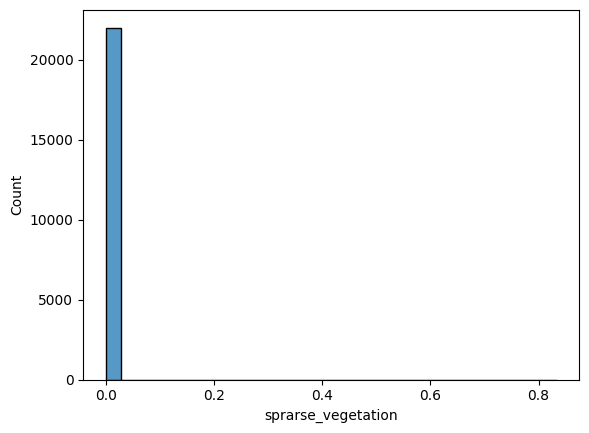

In [19]:
sns.histplot(data= data["sprarse_vegetation"], bins= 30)
plt.show()

The column is full of 0 so we can get ride of it.

Might look at the others

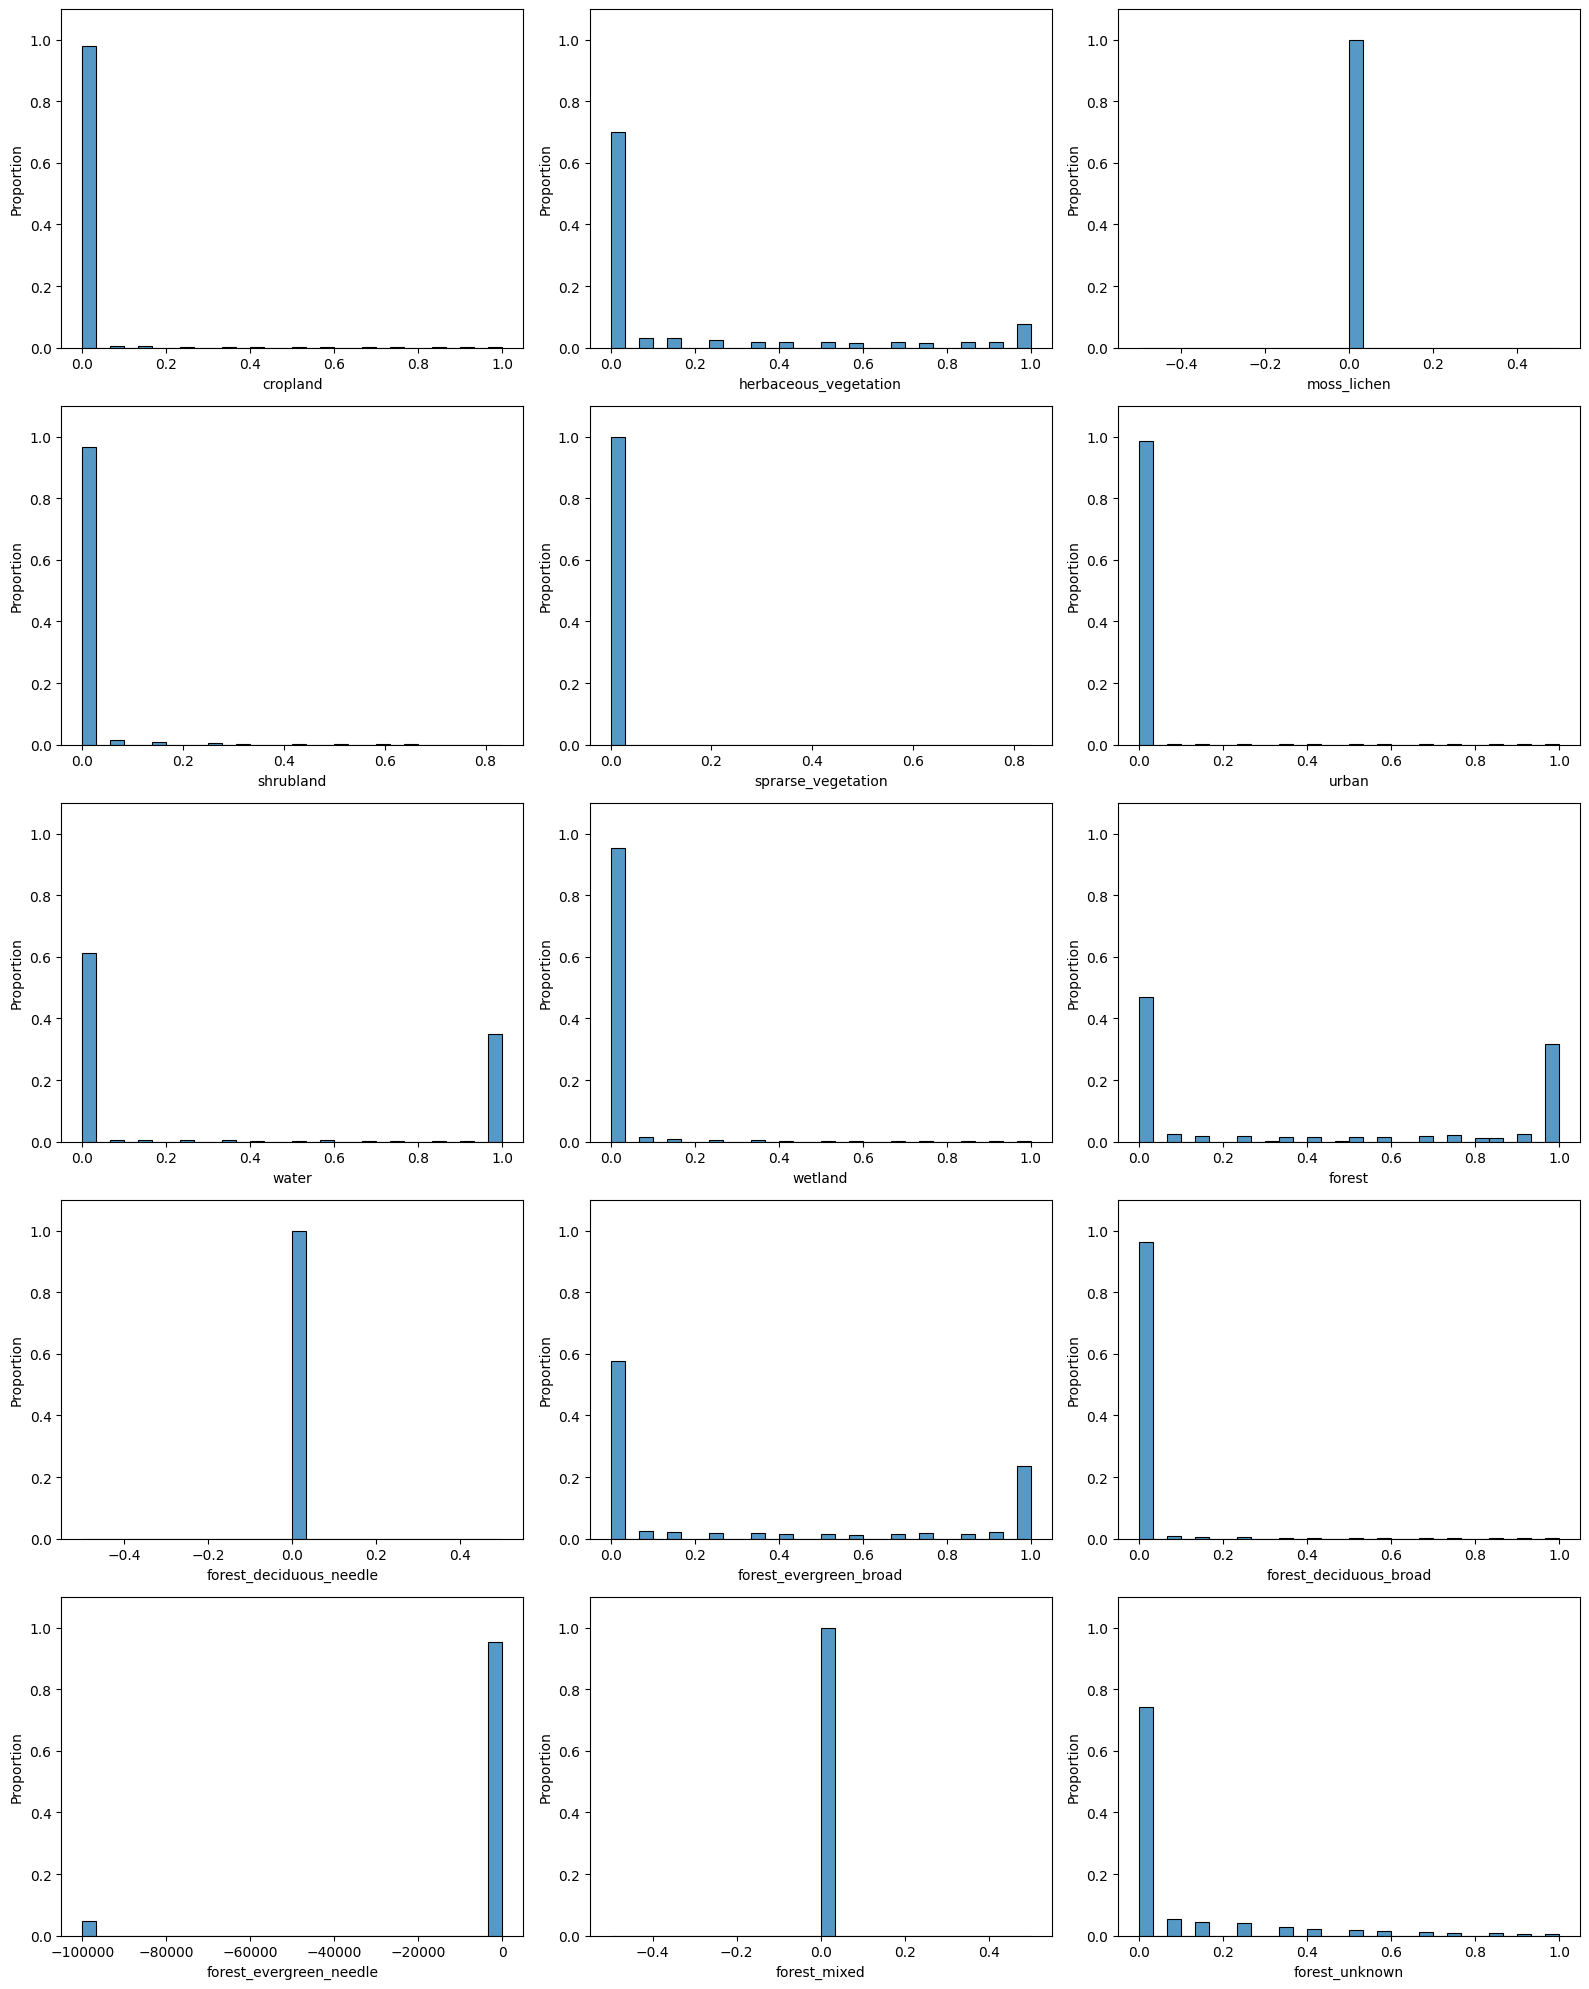

In [20]:
n_cols = len(vegetation_col[:-1]+ forest_type)
cols_per_row = 3
rows = int(np.ceil(n_cols / cols_per_row))

fig, ax = plt.subplots(rows, cols_per_row, figsize=(16, 4 * rows))
ax = ax.flatten()
for i, col in enumerate(vegetation_col[:-1]+ forest_type) : # Dropping the vegetation_class column for those histograms
    sns.histplot(data= data[col], bins= 30, ax=ax[i], stat='proportion')
    ax[i].set_ylim(0,1.1)

# remove empty axes if the number of columns is not a multiple of 3
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

We see for each vegetation class, most frequently, the proportion of the class is close to 0. So, I can assume that if i delete these columns and only keep the column called "vegetation_class", I won't lose that much of information

In [21]:
data1 = data.drop(columns=vegetation_col[:-1] + forest_type)
data1.columns

Index(['Date', 'distance_fire_stations', 'distance_rivers', 'distance_roads',
       'distance_powerlines', 'aspect', 'elevation', 'pop_dens', 'slope',
       'anom_max_temp', 'anom_max_wind_vel', 'anom_avg_temp',
       'anom_avg_rel_hum', 'anom_avg_soil', 'anom_sum_prec', 'max_temp',
       'max_wind_vel', 'avg_temp', 'avg_wind_angle', 'avg_rel_hum', 'avg_soil',
       'sum_prec', 'vegetation_class', 'Year', 'max_max_temp',
       'yearly_avg_temp', 'ignition'],
      dtype='object')

Now let's handle the yearly_avg_temp column, which contains 31% missing values.
Since we know the ignition year, a reasonable strategy is to fill each NA with the average temperature of the corresponding year.

Before doing that, let's take a look at the distribution to understand how this feature behaves.

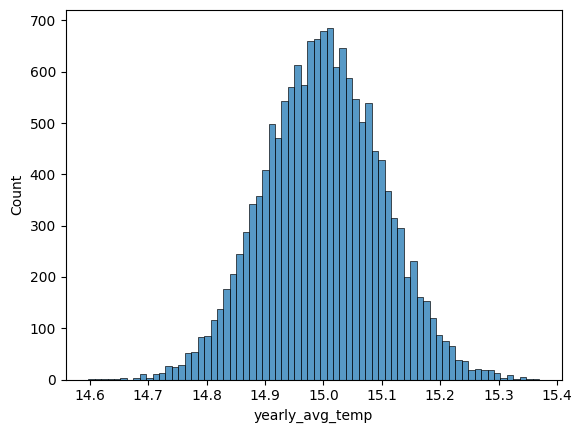

In [22]:
sns.histplot(data=data1["yearly_avg_temp"])
plt.show()

The distribution looks symmetric and without heavy tails, so filling missing values with the yearly average should work well.







In [23]:
data2 = data1.copy()

for year in data2['Year'].unique() :
    mask = data2['Year'] == year
    year_avg = data2.loc[mask,'yearly_avg_temp'].mean()
    data2.loc[mask, "yearly_avg_temp"] = data2.loc[mask, "yearly_avg_temp"].fillna(year_avg)


In [24]:
data2.isna().any()

,0
Date,False
distance_fire_stations,False
distance_rivers,False
distance_roads,False
distance_powerlines,False
aspect,False
elevation,False
pop_dens,False
slope,False
anom_max_temp,False


We are done with NAs now !!

## Distribution

In [25]:
data2.set_index(['Date'], inplace=True) # setting the date as index

In [26]:
data2.select_dtypes(['object', 'int']).columns

Index(['vegetation_class', 'Year', 'ignition'], dtype='object')

In [27]:
data2["ignition"].value_counts(normalize=True)

,proportion
ignition,
0,0.849296
1,0.150704


Kinda imbalanced, so we will stratify during spliting

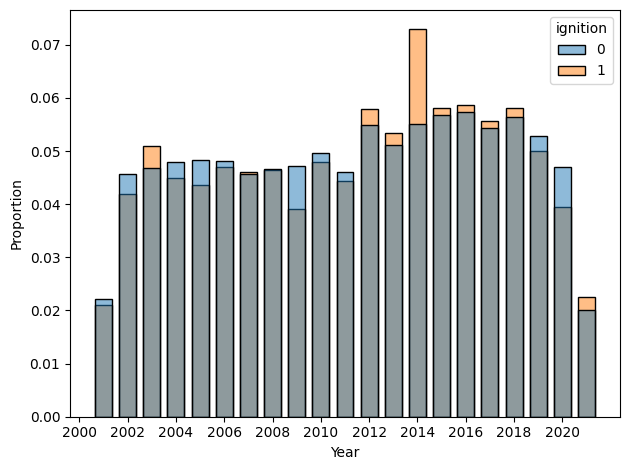

In [28]:
# barplot for the Year column
sns.histplot(data = data2, x = 'Year', hue='ignition',
             stat="proportion", common_norm=False, shrink=0.7, discrete=True)

plt.xticks(np.arange(2000,2022,2))
plt.tight_layout()
plt.show()

The year doesn't seems that discriminant.
More than that, the year only indicates when the data point was recorded and does not provide any direct information related to ignition. Keeping it could introduce temporal bias without adding predictive power.

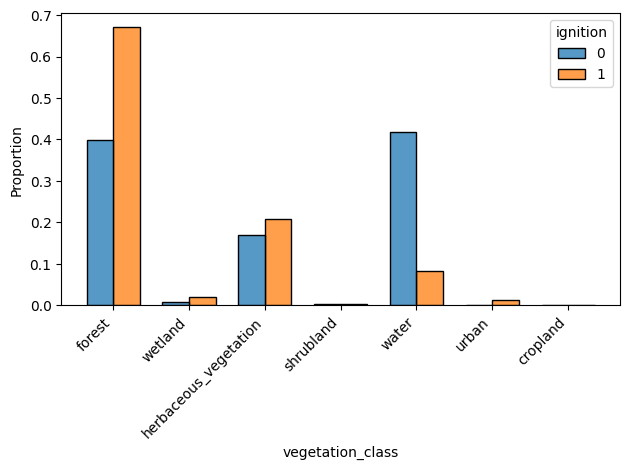

In [29]:
sns.histplot(data = data2, x = 'vegetation_class', hue='ignition',
             stat="proportion", common_norm=False, multiple="dodge", shrink=0.7)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

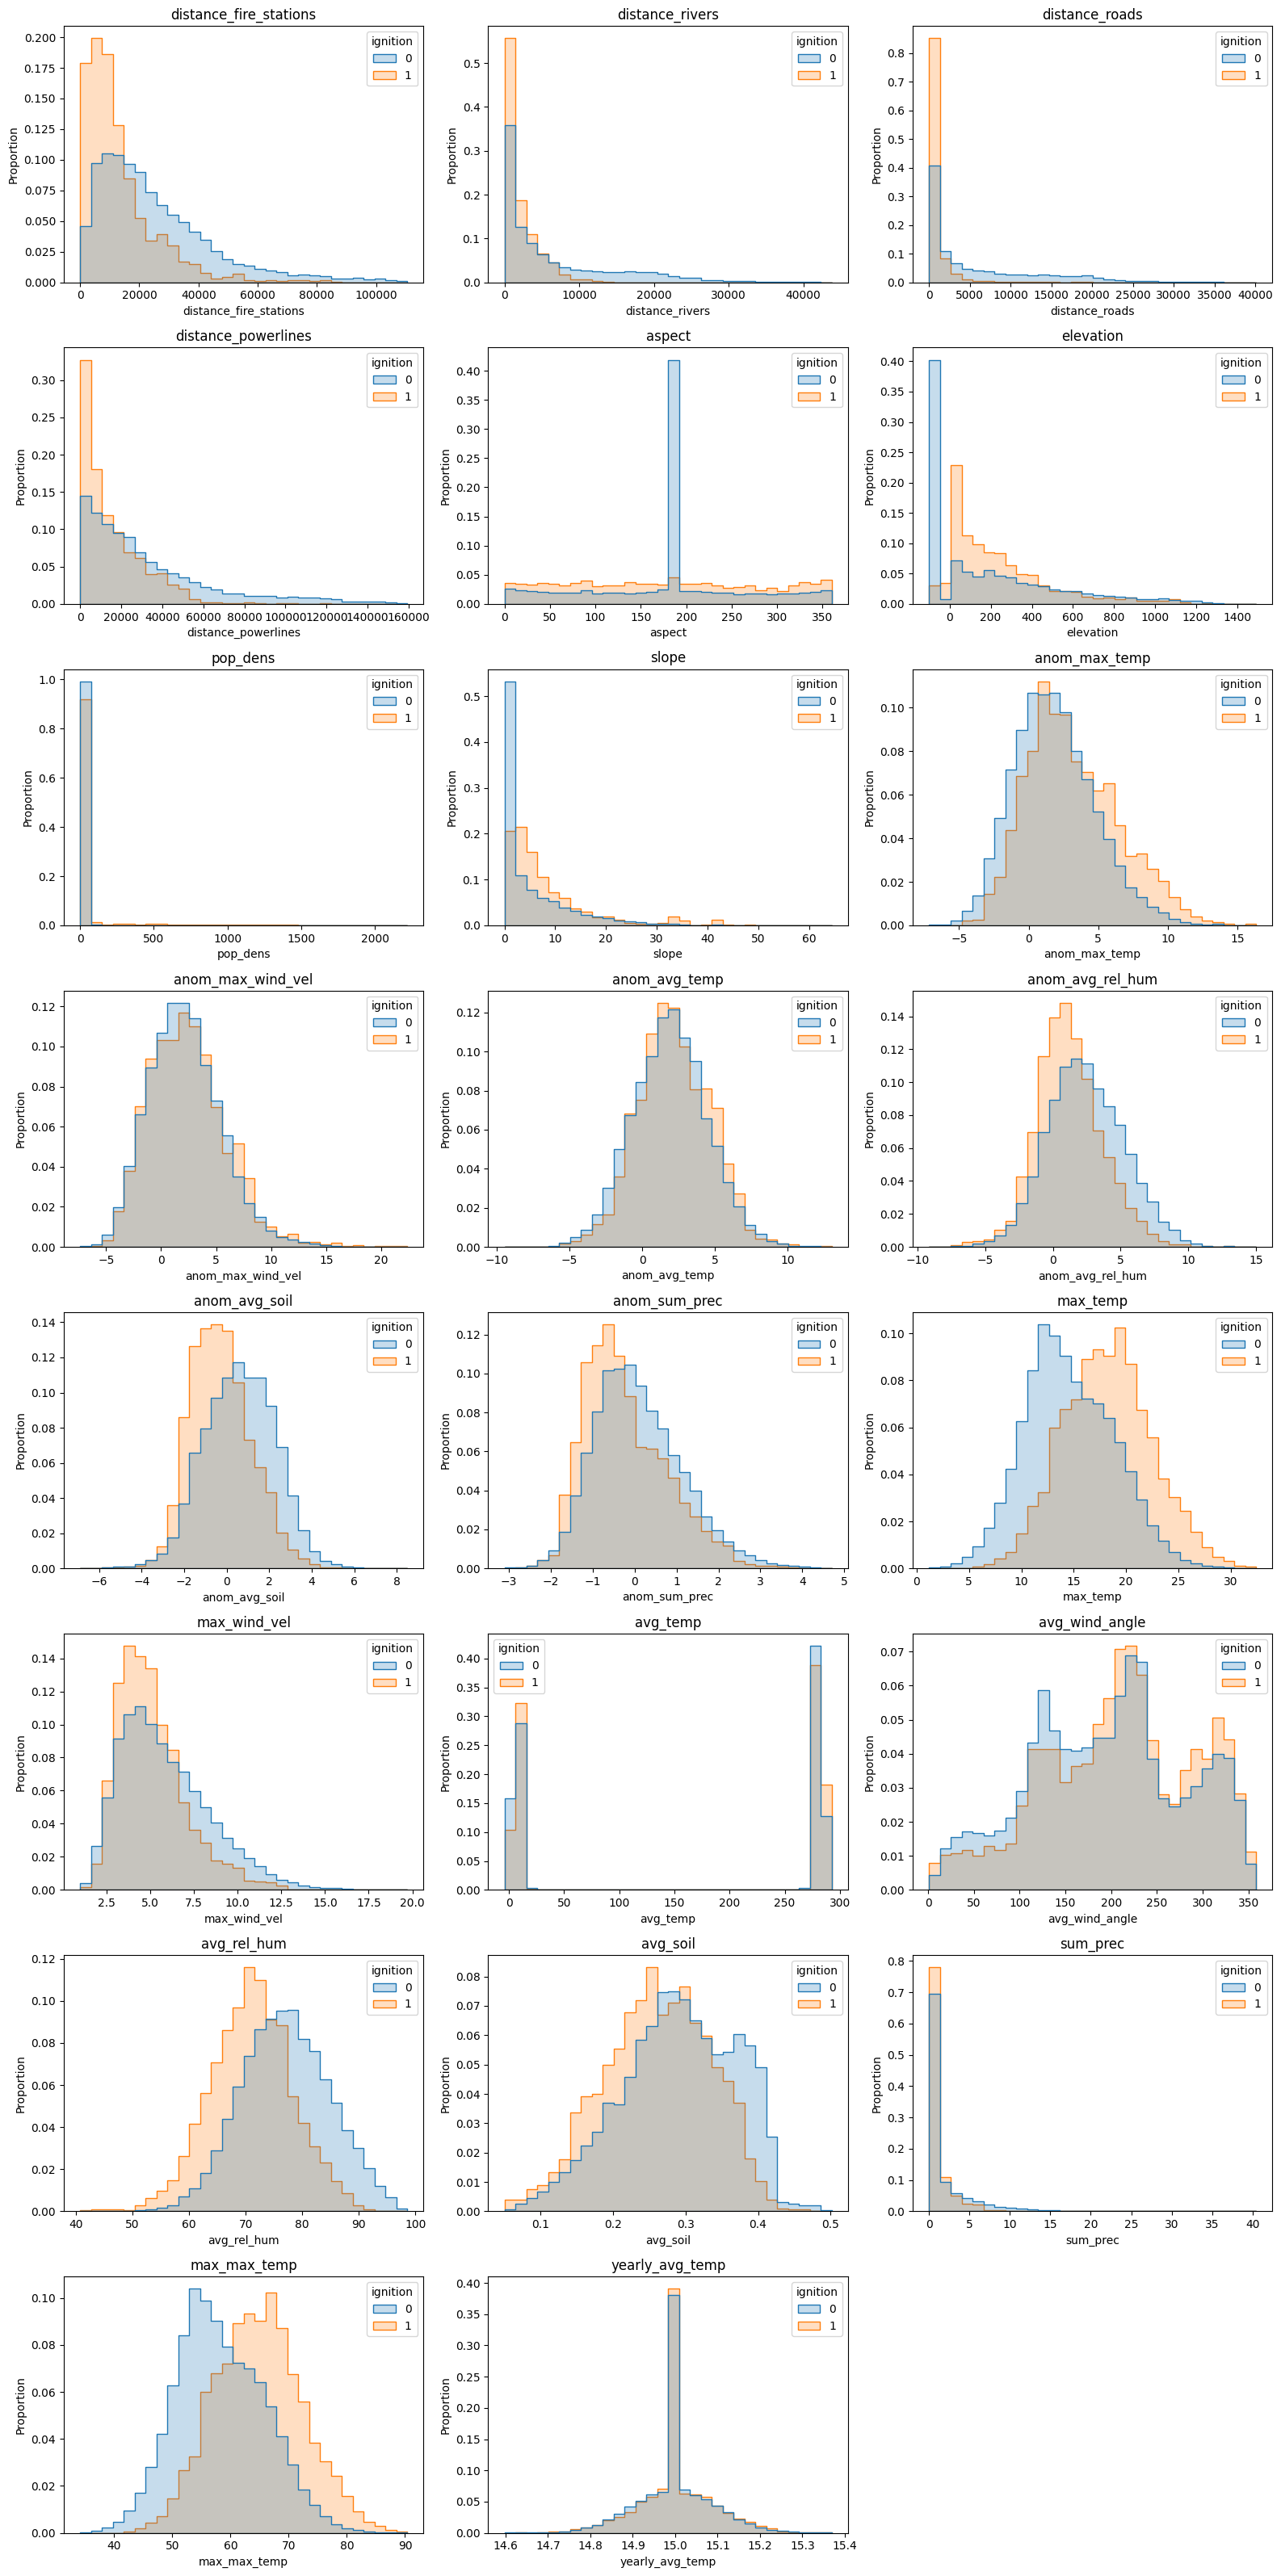

In [30]:
float_cols = data2.select_dtypes(include="float").columns
n_cols = len(float_cols)

# getting a clean layout
cols_per_row = 3
rows = int(np.ceil(n_cols / cols_per_row))

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    sns.histplot(
        data=data2,
        x=col,
        hue="ignition",
        bins=30,
        element="step",
        common_norm=False,
        stat='proportion',
        ax=axes[i]
    )
    axes[i].set_title(col)

# remove empty axes if the number of columns is not a multiple of 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1: Weird distribution for the average temp, more than 250 °C ?????

2: We can make the hypothesis that there is some diffenrence in the distribution depending on the target values for some features. Let's make a t-test

In [31]:
print(len(data2.loc[data2["avg_temp"] >= 250])/len(data2))

0.5548343168406719


About 55 percent of the values in this column are unrealistically high, even if the unit were Fahrenheit. It might be in Kelvin, but I am not sure, so I will just drop the column because the data were not properly recorded. Also, as the plot below shows, the average temperature does not seem to differ between ignition and non ignition points anyway.

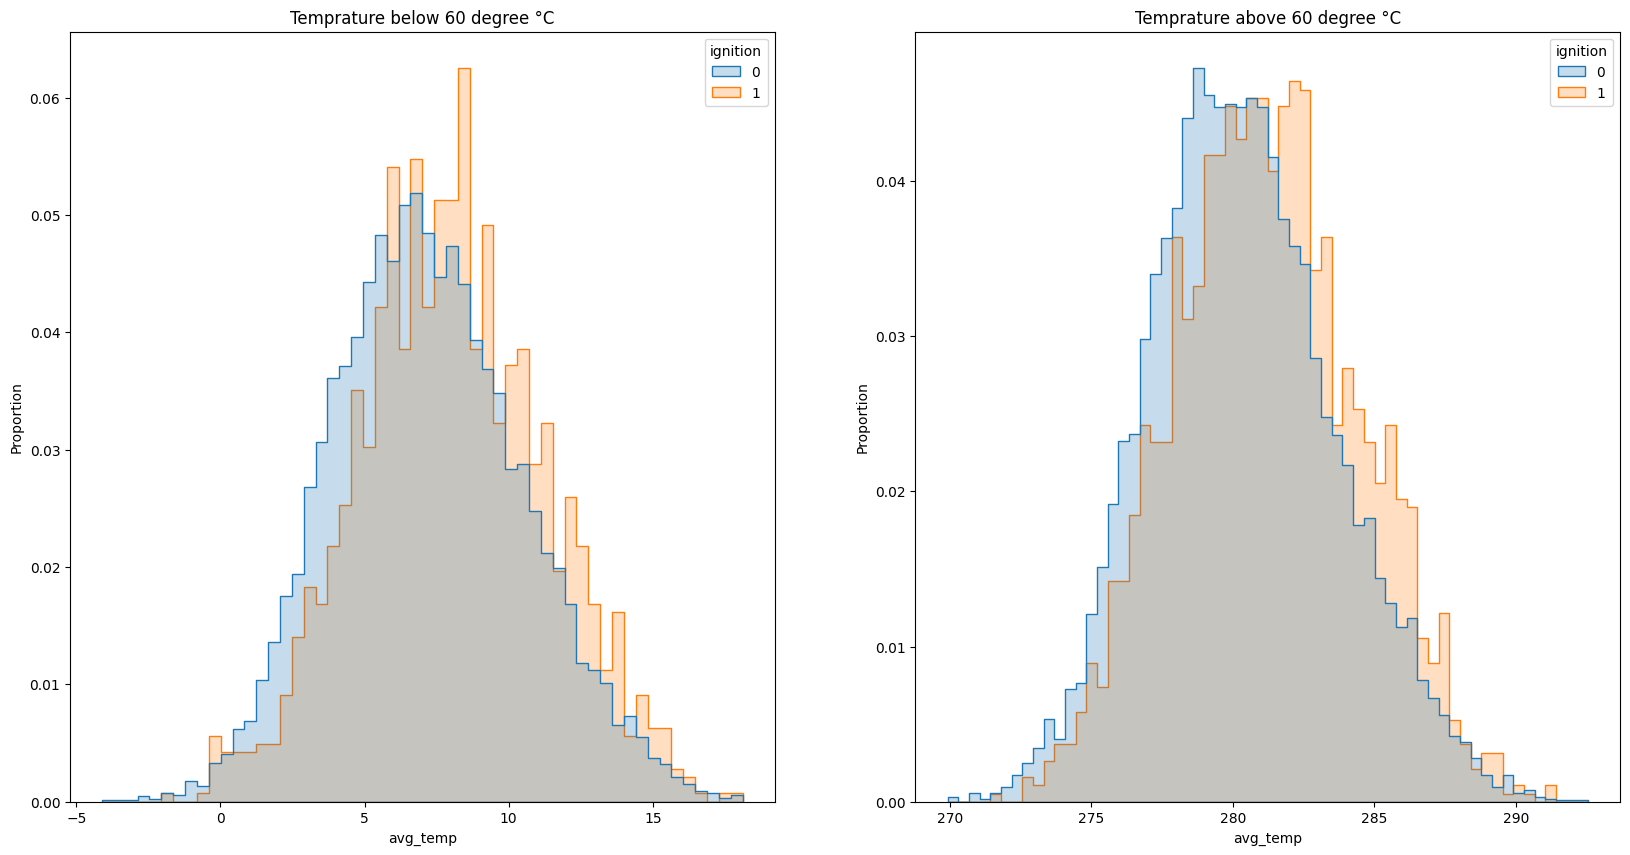

In [32]:
fig, ax = plt.subplots(1,2, figsize = (20,10))

# Temperatures below 60°C
sns.histplot(data = data2.loc[data2["avg_temp"] < 60], x='avg_temp', hue = 'ignition',
             ax = ax[0], element="step", common_norm=False,stat='proportion')
ax[0].set_title('Temprature below 60 degree °C')



# Temperatures above 60°C
sns.histplot(data = data2.loc[data2["avg_temp"] >= 60], x='avg_temp', hue = 'ignition',
             ax = ax[1],element="step", common_norm=False,stat='proportion')
ax[1].set_title('Temprature above 60 degree °C')


plt.show()

In [33]:
data3 = data2.drop(columns = ['avg_temp'])

In [34]:
from scipy.stats import ttest_ind

In [35]:
ignition = data3.loc[data3['ignition']==1]
not_ignition = data3.loc[data3['ignition']==0].sample(n = len(ignition), random_state=1) # since the target is unbalanced

alpha = 0.05

for col in data3.select_dtypes(include = 'float').columns :
    star, p_value = ttest_ind(not_ignition[col], ignition[col])
    if p_value < alpha :
        print(f'{col :-<25} HO rejected')
    else :
        print(f"{col :-<25} na")

distance_fire_stations--- HO rejected
distance_rivers---------- HO rejected
distance_roads----------- HO rejected
distance_powerlines------ HO rejected
aspect------------------- na
elevation---------------- HO rejected
pop_dens----------------- HO rejected
slope-------------------- HO rejected
anom_max_temp------------ HO rejected
anom_max_wind_vel-------- HO rejected
anom_avg_temp------------ HO rejected
anom_avg_rel_hum--------- HO rejected
anom_avg_soil------------ HO rejected
anom_sum_prec------------ HO rejected
max_temp----------------- HO rejected
max_wind_vel------------- HO rejected
avg_wind_angle----------- HO rejected
avg_rel_hum-------------- HO rejected
avg_soil----------------- HO rejected
sum_prec----------------- HO rejected
max_max_temp------------- HO rejected
yearly_avg_temp---------- na


In [36]:
print(data3['yearly_avg_temp'].mean(), data3['yearly_avg_temp'].std())

14.99973423685524 0.08365106607828113


Based on the t test results, all the features seem potentially useful for our prediction, except for yearly_avg_temp and aspect.

This actually makes sense for yearly_avg_temp tho. I will probably remove that column later because the dispertion is way to small

## Correlation

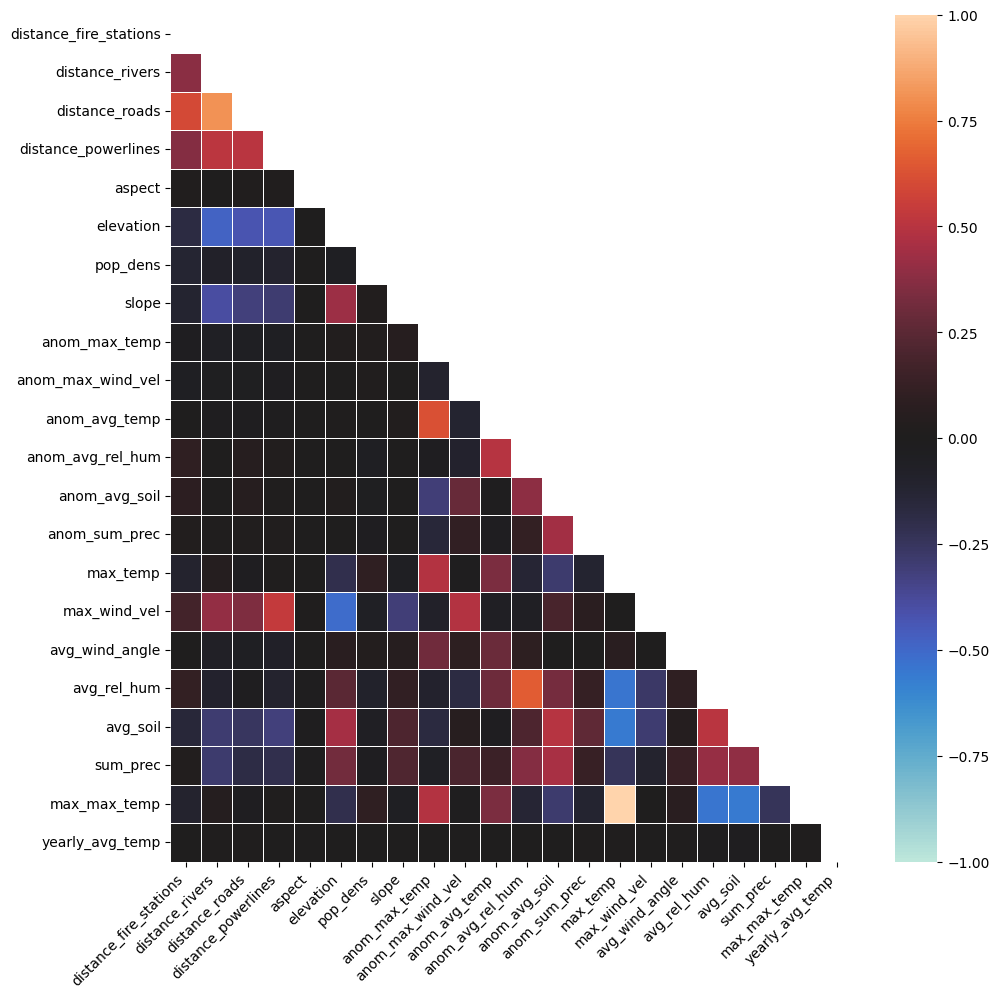

In [37]:
float_cols = data3.select_dtypes(include="float").columns

corr = data3[float_cols].corr(method= 'pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(11, 11))

sns.heatmap(corr, mask=mask, vmin=-1, vmax=1,  center=0,linewidths=.5)
plt.xticks(rotation=45, ha="right")
plt.show()

Insights :
- max_max_temp looks like a linear combination of max_temp, so we should probably drop it.
- The anomaly columns seem highly correlated with their normal average counterparts,
  so their distributions might actually be the same, we’ll test that later.
- distance_road and distance_rivers show a very high linear correlation.



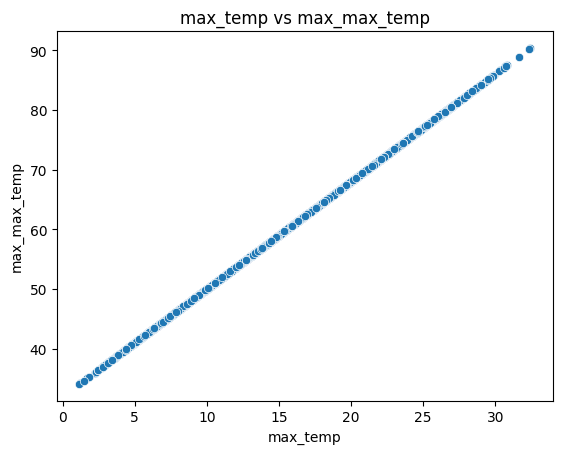

In [40]:
# Is max_max_temp a linear combination of max_temp ?

sns.scatterplot(data=data3, x='max_temp', y='max_max_temp')
plt.title('max_temp vs max_max_temp')
plt.show()

Hmmm, It’s not a strict linear combination, but the boxplot stays pretty narrow, so dropping this feature seems reasonable.

For testing anom vs classic, i will do a ks test

In [41]:
from scipy.stats import ks_2samp

In [42]:
classic = ['max_temp','max_wind_vel', 'avg_rel_hum', 'avg_soil', 'sum_prec']
anom = ['anom_max_temp','anom_max_wind_vel', 'anom_avg_rel_hum',
        'anom_avg_soil', 'anom_sum_prec']

alpha = 0.05
for i in range(len(classic)) :
  avg = data3[classic[i]].mean()
  std = data3[classic[i]].std()
  standardized_classic = (data3[classic[i]] - avg)/std
  stat, p_value = ks_2samp(standardized_classic, data3[anom[i]])
  if p_value < alpha :
    print(f'{anom[i]} / {classic[i] :-<25} HO rejected')
  else:
    print(f"{anom[i]} / {classic[i] :-<25} na")

anom_max_temp / max_temp----------------- HO rejected
anom_max_wind_vel / max_wind_vel------------- HO rejected
anom_avg_rel_hum / avg_rel_hum-------------- HO rejected
anom_avg_soil / avg_soil----------------- HO rejected
anom_sum_prec / sum_prec----------------- HO rejected


Ok ok so my assumption was statisticaly false. Can't really explain the linear correl then.

In [43]:
corr['distance_roads']['distance_rivers']

np.float64(0.8102616506347041)

The correlation is a bit high, but since we’re not relying on a linear model
(except maybe for a quick baseline), it's totally fine.

Now let's see the linear correlation between the target and other features

In [44]:
data3[float_cols.to_list() + ['ignition']].corr()['ignition'].sort_values(ascending=False)

,ignition
ignition,1.000000
max_max_temp,0.295061
max_temp,0.295061
pop_dens,0.164212
anom_max_temp,0.159961
slope,0.151001
avg_wind_angle,0.052935
elevation,0.052914
anom_avg_temp,0.040492
anom_max_wind_vel,0.028027


Not that much of correlation, a linear model like logistic regression will probably not be that great but still might be useful for a benchmark

# Preprocessing

In [45]:
# the final df

df_final = data3.drop(columns=['max_max_temp', 'Year', 'yearly_avg_temp'])

In [46]:
# print number of categories for vgetation_class

print(df_final['vegetation_class'].unique().shape[0])

7


Let's do the prepocessing now,

- Float features: we apply a StandardScaler. Tree-based models are scale-invariant, but we still standardize for consistency across all models.

- vegetation_class: this feature has 7 categories. We will try both one-hot encoding and frequency encoding, then compare which option works best in practice.







In [49]:
pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 5.8 MB/s eta 0:00:00


In [50]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from feature_engine.encoding import CountFrequencyEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [51]:
# Splitting the dataset into features and target variable

X = df_final.drop(columns='ignition')

y = df_final['ignition']

In [52]:
float_cols = X.select_dtypes(include="float").columns.to_list()
cat_col = X.select_dtypes(include="object").columns.to_list()

In [53]:
# pipeline for one hot encoder

pipeline_one_hot = Pipeline([
    ('preprocessor_one_hot', ColumnTransformer(
        transformers=[
            ('num_pipe', StandardScaler(), float_cols),
            ('cat_pipe', OneHotEncoder(sparse_output=False), cat_col)]
))])

# pipeline for frequency encoder

pipeline_freq = Pipeline([
    ('preprocessor_freq', ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), float_cols),
            ('cat', CountFrequencyEncoder(encoding_method='frequency'), cat_col)]
))])

In [54]:
# Function to get back a df from a pipeline transformed df
def pipeline_to_df(pipeline, X, prep_name):
    prep = pipeline.named_steps[prep_name]
    X_arr = prep.fit_transform(X)
    try:
        cols = prep.get_feature_names_out()
    except AttributeError:
        cols = X.columns
    return pd.DataFrame(X_arr, columns=cols, index=X.index)

X_oh_df   = pipeline_to_df(pipeline_one_hot, X, "preprocessor_one_hot")
X_freq_df = pipeline_to_df(pipeline_freq, X, "preprocessor_freq")

In [55]:
# Train test split for both One Hot version and frequency version
# Note that we don't need to change y, the splitting is the same


X_train_OH, X_test_OH, y_train_, y_test_ = train_test_split(X_oh_df, y, random_state=1, stratify=y, train_size=0.7)
X_train_freq, X_test_freq, y_train_, y_test_ = train_test_split(X_freq_df, y, random_state=1, stratify=y, train_size=0.7)

In [56]:
X_train_freq.head()

,num__distance_fire_stations,num__distance_rivers,num__distance_roads,num__distance_powerlines,num__aspect,num__elevation,num__pop_dens,num__slope,num__anom_max_temp,num__anom_max_wind_vel,num__anom_avg_temp,num__anom_avg_rel_hum,num__anom_avg_soil,num__anom_sum_prec,num__max_temp,num__max_wind_vel,num__avg_wind_angle,num__avg_rel_hum,num__avg_soil,num__sum_prec,cat__vegetation_class
Date,,,,,,,,,,,,,,,,,,,,,
2016-12-18,-0.655100,-0.580933,-0.707997,-0.826544,1.280610,1.174305,-0.115948,1.683229,0.825208,1.007953,-0.324051,0.098810,0.290021,-1.022851,0.695580,-0.092919,1.545680,-0.782970,1.109859,0.183246,0.439083
2018-06-13,3.850558,1.084270,3.717674,0.962567,0.029851,-0.905974,-0.118128,-0.720201,2.575034,-0.061851,0.649424,-0.382509,-1.647820,-1.142404,1.891119,-0.128842,-1.569282,-0.647424,-2.127805,-0.514875,0.368044
2005-07-26,-0.915700,-0.793931,-0.693043,-0.934522,-0.472748,-0.161453,-0.113487,0.468511,0.018213,0.518608,-1.491373,0.417574,0.320905,-0.849392,-1.748649,-0.432283,1.662510,1.255238,1.516757,1.185962,0.439083
2018-05-05,-1.136657,-0.660872,-0.693043,-0.672069,0.176553,-0.095760,-0.025998,-0.398636,1.450740,-0.020375,0.951264,0.220158,0.654071,1.475492,-0.014682,-0.658058,-0.812947,-0.300037,0.398336,-0.111238,0.174807
2016-03-23,0.688706,1.681995,1.566785,0.419573,0.029851,-0.905974,-0.118128,-0.720201,-1.325771,-1.196472,-1.250428,-0.089741,-0.175812,-0.418729,-0.535969,0.132949,-0.292764,0.067448,-0.729984,-0.514875,0.368044


# Modelling

We will test multiple models:
- Logistic regression
- Random Forest
- XGboost
- SVM
- Neural network

Then we will select the best one and try to optimize it.

To evaluate the performance of the model, we use F1-score, recall, and PR-AUC, which are appropriate metrics since the target is unbalanced.

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.metrics import Precision as precision
from tensorflow.keras.metrics import Recall as recall
from tensorflow.keras.metrics import AUC as auc
from sklearn.metrics import f1_score, recall_score, average_precision_score, precision_score
import time

In [58]:
# Compute the positive class weight because the target is imbalanced
pos_class_weight = (len(y) - np.sum(y)) / np.sum(y)
weight = {0:1, 1:pos_class_weight}

# Listing our models
dico_models = {'Logistic regression' : LogisticRegression(class_weight=weight, random_state=0),
          'Random forest' : RandomForestClassifier(class_weight='balanced_subsample', random_state=0),
          'XGboost' : XGBClassifier(scale_pos_weight = pos_class_weight, random_state=0),
          'SVM' : SVC(class_weight=weight, probability=True, random_state=0)}



In [59]:
# Fonction to get the training time of a model in a nice format

def format_time(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return hours, minutes, secs

In [60]:
# Fonction to store each models results

def models_evaluation(x_train, x_test, y_train, y_test):
  results = {}
  for model_name, model in dico_models.items():

    start = time.time()
    model.fit(x_train, y_train)
    duration = time.time() - start

    # convert duration to h/m/s
    h, m, s = format_time(duration)

    # prediction
    y_pred = model.predict(x_test)

    # probabilities for PR-AUC
    y_score = model.predict_proba(x_test)[:, 1]

    # storage
    results[model_name] = {'f1_score' : f1_score(y_test, y_pred),
                           'precision' : precision_score(y_test, y_pred),
                           'recall' : recall_score(y_test, y_pred),
                           'pr_auc' : average_precision_score(y_test, y_score),
                           'fitted_model' : model, # will be useful for the Random Forest features importance
                           'name' : model_name}

    # pretty print
    print(f"{model_name} completed in {h}h {m}m {s}s")
  return (results)

In [61]:
results_OH = models_evaluation(X_train_OH, X_test_OH, y_train_, y_test_)

Logistic regression completed in 0h 0m 0s
Random forest completed in 0h 0m 11s
XGboost completed in 0h 0m 3s
SVM completed in 0h 0m 49s


In [62]:
results_freq = models_evaluation(X_train_freq, X_test_freq, y_train_, y_test_)

Logistic regression completed in 0h 0m 0s
Random forest completed in 0h 0m 6s
XGboost completed in 0h 0m 1s
SVM completed in 0h 0m 41s


Let' compute a fonction to get a dataframe from the results dictionnary. It will be useful for plotting the metrics

In [63]:
def dico_results_to_df(results):
    rows = []

    for model_name, metrics in results.items():
        rows.append({
            "name": metrics["name"],
            "recall": metrics["recall"],
            "precision": metrics["precision"],
            "f1_score": metrics["f1_score"],
            "pr_auc": metrics["pr_auc"]
        })

    df = pd.DataFrame(rows)
    return df


In [65]:
# Comparing One Hot Encoder vs Frenquency encoder

results_OH_df = dico_results_to_df(results_OH).round(2)

results_freq_df = dico_results_to_df(results_freq).round(2)

print ('One Hot Encoding\n', results_OH_df, '\n\n\nFrequency Encoding\n',results_freq_df)

One Hot Encoding
                   name  recall  precision  f1_score  pr_auc
0  Logistic regression    0.85       0.38      0.53    0.53
1        Random forest    0.44       0.78      0.56    0.71
2              XGboost    0.70       0.59      0.64    0.71
3                  SVM    0.89       0.43      0.58    0.56 


Frequency Encoding
                   name  recall  precision  f1_score  pr_auc
0  Logistic regression    0.85       0.38      0.52    0.53
1        Random forest    0.43       0.77      0.56    0.70
2              XGboost    0.72       0.59      0.65    0.71
3                  SVM    0.89       0.42      0.57    0.54


For our problem, frequency encoding is equivalent to One hot encoding.

We are keeping the One hot version

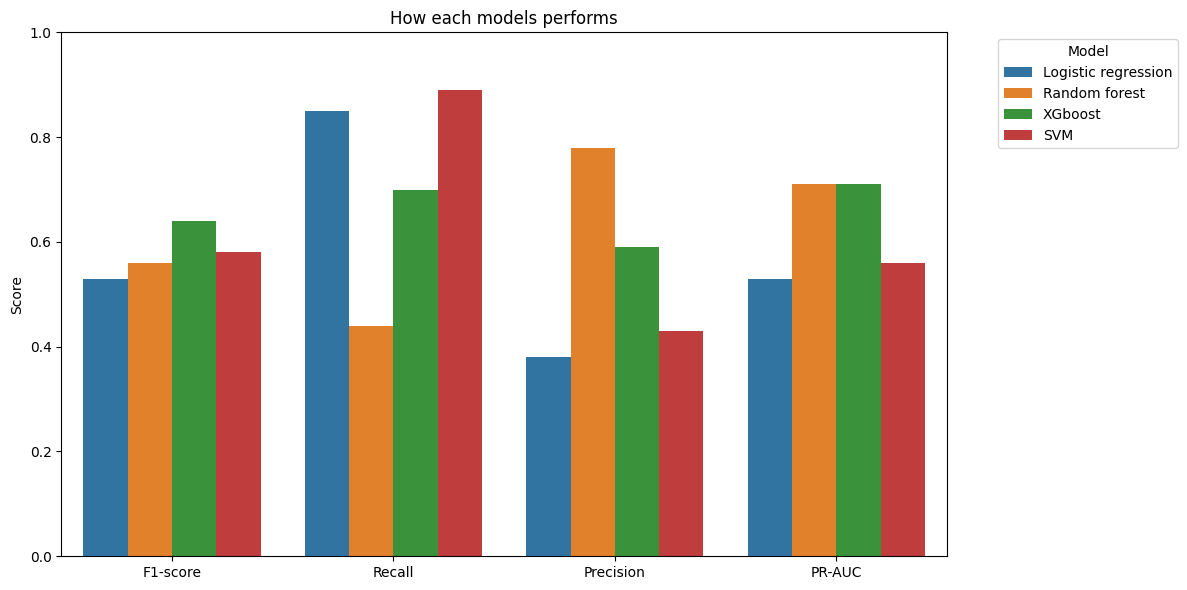

In [66]:
# cool little list of the metrics we want to show
metrics = ["f1_score", "recall", "precision", "pr_auc"]

# reshape the results into a long-format table
long_df = results_OH_df.melt(
    id_vars="name",
    value_vars=metrics,
    var_name="metric",
    value_name="score"
)

# nicer names for the plot
metric_titles = {
    "f1_score": "F1-score",
    "recall": "Recall",
    "precision": "Precision",
    "pr_auc": "PR-AUC"
}
long_df["metric"] = long_df["metric"].map(metric_titles)

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=long_df,
    x="metric",
    y="score",
    hue="name"
)

# cleaner plot
plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Score")
plt.title("How each models performs")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


Among the tested models, XGBoost achieved the best overall performance, with the highest F1-score and PR-AUC. It provides a good balance between recall and precision, detecting ignition points without generating too many false alarms. Logistic Regression and SVM achieved very high recall but produced a large number of false positives, resulting in low precision. On the other hand, Random Forest was overly conservative, with strong precision but a low recall, meaning it missed many actual ignition points. Overall, XGBoost appears to offer the most reliable trade-off for this imbalanced classification task.

Let's compare XGboost with a neural network.

In [72]:
input_dim = X_train_OH.shape[1]

model_nn = models.Sequential()

# input layer
model_nn.add(Input(shape=(input_dim,)))

# hidden layers
model_nn.add(layers.Dense(128, activation='sigmoid', kernel_initializer='glorot_uniform'))
model_nn.add(layers.Dropout(0.3)) # dropout method to prevent from overfitting

model_nn.add(layers.Dense(64, activation='sigmoid', kernel_initializer='glorot_uniform'))
model_nn.add(layers.Dropout(0.3))

model_nn.add(layers.Dense(32, activation='sigmoid', kernel_initializer='glorot_uniform'))
model_nn.add(layers.Dropout(0.3))

model_nn.add(layers.Dense(16, activation='sigmoid', kernel_initializer='glorot_uniform'))
model_nn.add(layers.Dropout(0.3))

# output layer: sigmoid for binary classification
model_nn.add(layers.Dense(1, activation='sigmoid'))

model_nn.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=[precision(name='precision'),
                       auc(name='pr_auc', curve='PR'),
                       recall(name='recall'),
                       ])

In [73]:
history = model_nn.fit(X_train_OH, y_train_, epochs=100, validation_data = (X_test_OH, y_test_),
                    class_weight=weight, batch_size= 256)

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - loss: 1.2870 - pr_auc: 0.1500 - precision: 0.1421 - recall: 0.1819 - val_loss: 0.7049 - val_pr_auc: 0.3502 - val_precision: 0.1507 - val_recall: 1.0000
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 1.2077 - pr_auc: 0.1593 - precision: 0.1623 - recall: 0.5310 - val_loss: 0.6552 - val_pr_auc: 0.4718 - val_precision: 0.4739 - val_recall: 0.5743
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1317 - pr_auc: 0.2160 - precision: 0.2093 - recall: 0.5261 - val_loss: 0.5759 - val_pr_auc: 0.4887 - val_precision: 0.3157 - val_recall: 0.8996
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9464 - pr_auc: 0.3516 - precision: 0.3069 - recall: 0.8076 - val_loss: 0.4828 - val_pr_auc: 0.5090 - val_precision: 0.3631 - val_recall: 0.8695
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8451 - pr_auc: 0.4041 - precision: 0.3521 - recall: 0.8439 - val_loss: 0.4932 - val_pr_auc: 0.5074 - val_precision: 

In [74]:
# Manually computing the F1-score, since keras.metrics.F1Score was not behaving as expected

train_prec = np.array(history.history["precision"])
train_rec  = np.array(history.history["recall"])

val_prec = np.array(history.history["val_precision"])
val_rec  = np.array(history.history["val_recall"])

history.history["f1_score"] = 2 * (train_prec * train_rec) / (train_prec + train_rec + 1e-8)
history.history["val_f1_score"] = 2 * (val_prec * val_rec) / (val_prec + val_rec + 1e-8)

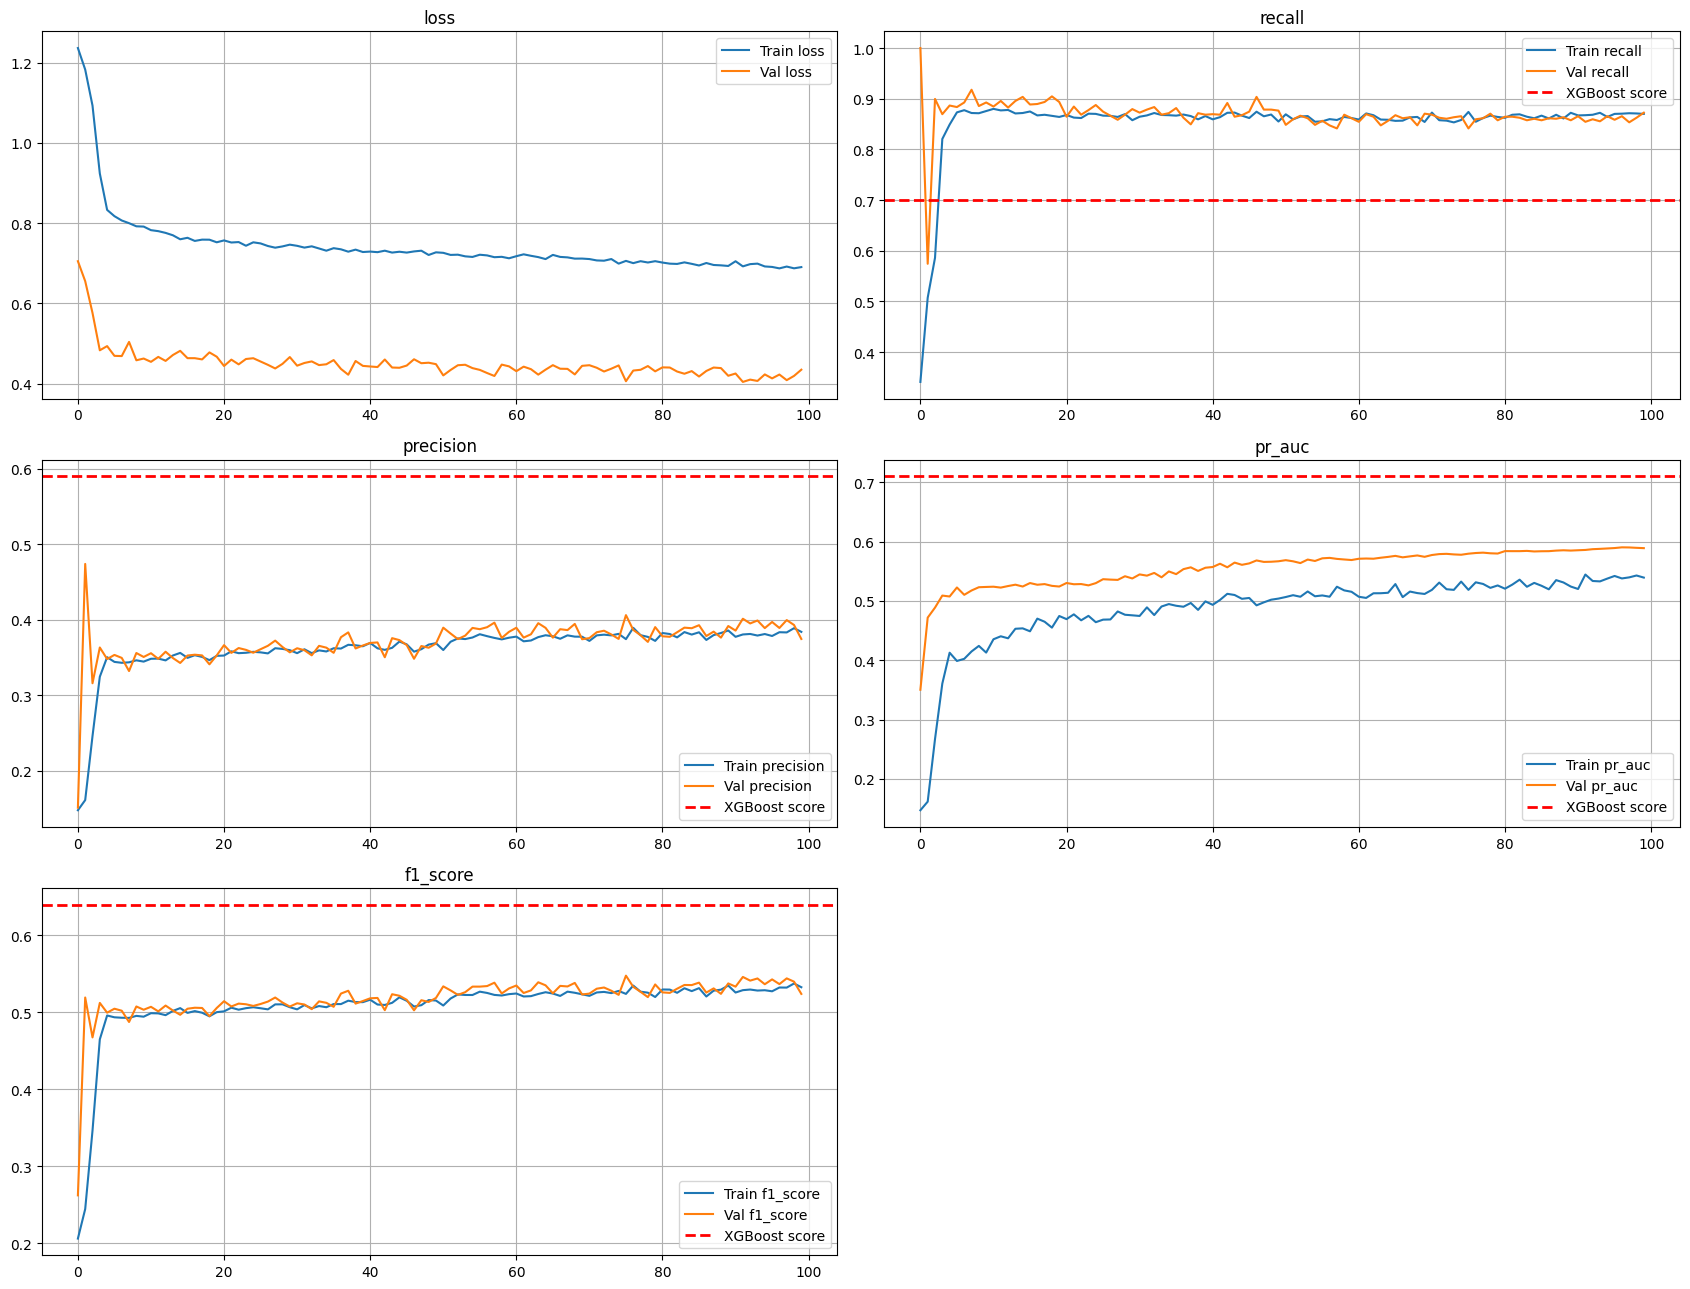

In [75]:
# Metrics we want to visualize across training
metrics_to_plot = ["loss", "recall", "precision", "pr_auc", 'f1_score']

# XGBoost benchmark scores to compare against the neural network curves
xgb_scores = {
    "loss": None,
    "recall": 0.70,
    "precision": 0.59,
    "pr_auc": 0.71,
    "f1_score": 0.64
}

plt.figure(figsize=(17,13))

for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(3, 2, i)
    sns.lineplot(history.history[metric], label=f"Train {metric}")
    sns.lineplot(history.history[f"val_{metric}"], label=f"Val {metric}")
    plt.title(metric)

    plt.grid(True)

    # Add a horizontal line showing the XGBoost performance
    if xgb_scores[metric] is not None:
        plt.axhline(
            y=xgb_scores[metric],
            color="red",
            linestyle="--",
            linewidth=2,
            label="XGBoost score"
        )
    plt.legend()

plt.tight_layout()
plt.show()


Although the neural network achieves a very high recall, the XGBoost model provides a much better overall balance, with higher precision, F1-score and PR-AUC. Given its superior performance, greater stability and suitability for tabular data, XGBoost was selected as the primary model to optimize.

In [76]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, average_precision_score

In [77]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight = pos_class_weight,
    n_jobs=-1
)

# Define the hyperparameter search space
param_dist = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 1, 3]
}


# Define scoring: we optimize PR-AUC (the best metric for imbalance)

scorer = make_scorer(average_precision_score, response_method='predict_proba')

# 4. RandomizedSearchCV setup

random_search = RandomizedSearchCV(
    error_score='raise',       # helps if i get an error
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,                 # number of random configurations tested
    scoring=scorer,            # maximize PR-AUC
    cv=3,                      # 5-fold cross validation
    verbose=2,                 # show progress
    n_jobs=-1,                 # use all processors
    random_state=1
)



In [78]:
# Fit the search
random_search.fit(X_train_OH, y_train_)
best_xgb = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [79]:
y_proba_xgb_best = best_xgb.predict_proba(X_test_OH)[:, 1]
y_pred_xgb_best = (y_proba_xgb_best >= 0.5).astype(int)

# 2) Metrics
rec = recall_score(y_test_, y_pred_xgb_best)
prec = precision_score(y_test_, y_pred_xgb_best)
f1 = f1_score(y_test_, y_pred_xgb_best)
pr_auc = average_precision_score(y_test_, y_proba_xgb_best)

print("Tuned XGBoost performance :\n")
print(f"Recall   : {rec:.3f}")
print(f"Precision: {prec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"PR-AUC   : {pr_auc:.3f}")

Tuned XGBoost performance :

Recall   : 0.728
Precision: 0.597
F1-score : 0.656
PR-AUC   : 0.728


After tuning, the XGBoost model performs a bit better.

In [ ]:
from sklearn.metrics import precision_recall_curve

In [ ]:
# Compute PR curve
precision, recall, thresholds = precision_recall_curve(y_test_, y_proba_xgb_best)

# Put everything into a dataframe
pr_df = pd.DataFrame({
    "recall": recall,
    "precision": precision
})

# Plot
plt.figure(figsize=(8,6))
sns.lineplot(data=pr_df, x="recall", y="precision", linewidth=2)

plt.title(f"Precision–Recall Curve (XGBoost tuned)\nPR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)

plt.show()

In [ ]:
# Function to remove pipeline prefixes like "num_pipe__" or "cat_pipe__"
def clean_feature_name(name):
    name = name.replace("num_pipe__", "")
    name = name.replace("cat_pipe__", "")

    # Replace underscores with spaces for prettier labels
    name = name.replace("_", " ")

    return name

In [ ]:
booster = best_xgb.get_booster()
score_gain = booster.get_score(importance_type="gain")

# Convert to dataframe
fi_gain_df = pd.DataFrame(
    list(score_gain.items()),
    columns=["feature", "importance"]
).sort_values("importance", ascending=False)

top_n = 20
fi_gain_top = fi_gain_df.head(top_n)

fi_gain_top.loc[:,["clean_feature"]] = fi_gain_top["feature"].apply(clean_feature_name)

In [ ]:
# Plotting importance by gain

plt.figure(figsize=(10, 8))
sns.barplot(
    data=fi_gain_top,
    x="importance",
    y="clean_feature"
)
plt.title("Top feature importances by gain (XGBoost tuned)")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


- Distance to roads and slope stand out as the strongest predictors, suggesting that terrain characteristics greatly influence ignition point probability.

- Meteorological variables such as relative humidity and maximum temperature also play a significant role, which aligns with the physical drivers of fire ignition.

Overall, the model relies on a combination environmental, and climatic factors to detect ignition points.